# Tourism Domain (Marketing)



## Business Objective

The company “Trips & Travel.com” wants to efficiently market a new Wellness Tourism Package by identifying the most promising customers using data insights.


The goal of this notebook is to:

- Explore and understand the dataset.

- Find patterns that influence whether a customer purchased a product (ProdTaken).

- Provide actionable insights for marketing decisions.

## Importing Required Libraries

In [1]:
## Importing core libraries
import pandas as pd
import numpy as np

## Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## Loading and Inspect Dataset

In [2]:
# Load dataset
df = pd.read_csv("travel_dataset.csv")

# Sample first 5 rows
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


## Basic Dataset Information

In [3]:
print("Shape of the dataset:", df.shape)

Shape of the dataset: (4888, 20)


In [4]:
print("\nColumn Data Types:\n")
print(df.dtypes)


Column Data Types:

CustomerID                    int64
ProdTaken                     int64
Age                         float64
TypeofContact                object
CityTier                      int64
DurationOfPitch             float64
Occupation                   object
Gender                       object
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched               object
PreferredPropertyStar       float64
MaritalStatus                object
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                  object
MonthlyIncome               float64
dtype: object


In [6]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float6

In [7]:
print("\nSummary statistics for numeric columns:")
df.describe().T


Summary statistics for numeric columns:


,count,mean,std,min,25%,50%,75%,max
CustomerID,4888.0,202443.500000,1411.188388,200000.0,201221.75,202443.5,203665.25,204887.0
ProdTaken,4888.0,0.188216,0.390925,0.0,0.00,0.0,0.00,1.0
Age,4662.0,37.622265,9.316387,18.0,31.00,36.0,44.00,61.0
CityTier,4888.0,1.654255,0.916583,1.0,1.00,1.0,3.00,3.0
DurationOfPitch,4637.0,15.490835,8.519643,5.0,9.00,13.0,20.00,127.0
NumberOfPersonVisiting,4888.0,2.905074,0.724891,1.0,2.00,3.0,3.00,5.0
NumberOfFollowups,4843.0,3.708445,1.002509,1.0,3.00,4.0,4.00,6.0
PreferredPropertyStar,4862.0,3.581037,0.798009,3.0,3.00,3.0,4.00,5.0
NumberOfTrips,4748.0,3.236521,1.849019,1.0,2.00,3.0,4.00,22.0
Passport,4888.0,0.290917,0.454232,0.0,0.00,0.0,1.00,1.0


## Checking Missing Values

In [9]:
# Count of missing values
missing = df.isnull().sum().sort_values(ascending=False)
pd.DataFrame({"Missing Values": missing})


,Missing Values
DurationOfPitch,251
MonthlyIncome,233
Age,226
NumberOfTrips,140
NumberOfChildrenVisiting,66
NumberOfFollowups,45
PreferredPropertyStar,26
TypeofContact,25
Designation,0
OwnCar,0


In [10]:
# droping columns because i doesn't make sense 
df.drop(['CustomerID'] , axis = 1 , inplace = True)

## Checking for Duplicates

In [11]:
# Count of Duplicates
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")


Number of duplicate rows: 141


In [12]:
# Drop duplicates
df.drop_duplicates(inplace = True)

In [13]:
df.shape

(4747, 19)

## Data Cleaning

In [14]:
# Strip extra spaces and fix inconsistent text
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.title()

In [15]:
# Categorical column value counts
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(df[col].value_counts(dropna=False))


Self Enquiry       3350
Company Invited    1372
NaN                  25
Name: TypeofContact, dtype: int64
Salaried          2293
Small Business    2028
Large Business     424
Free Lancer          2
Name: Occupation, dtype: int64
Male       2835
Female     1769
Fe Male     143
Name: Gender, dtype: int64
Basic           1800
Deluxe          1684
Standard         714
Super Deluxe     324
King             225
Name: ProductPitched, dtype: int64
Married      2279
Divorced      950
Single        875
Unmarried     643
Name: MaritalStatus, dtype: int64
Executive         1800
Manager           1684
Senior Manager     714
Avp                324
Vp                 225
Name: Designation, dtype: int64


In [16]:
#fixing inconsistent gender values
df['Gender'] = df['Gender'].replace('Fe Male', 'Female')

## Handle Missing Values

In [17]:
# Numeric columns - filling with median
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [18]:
num_cols

Index(['ProdTaken', 'Age', 'CityTier', 'DurationOfPitch',
       'NumberOfPersonVisiting', 'NumberOfFollowups', 'PreferredPropertyStar',
       'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar',
       'NumberOfChildrenVisiting', 'MonthlyIncome'],
      dtype='object')

In [19]:
# Categorical columns - filling with mode
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[col].mode()[0])

In [20]:
cat_cols

Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object')

In [21]:
df.isnull().sum()

ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [22]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [23]:
print("Shape of the dataset After cleaning:", df.shape)

Shape of the dataset After cleaning: (4747, 19)


## Outlier Detection & Visualization

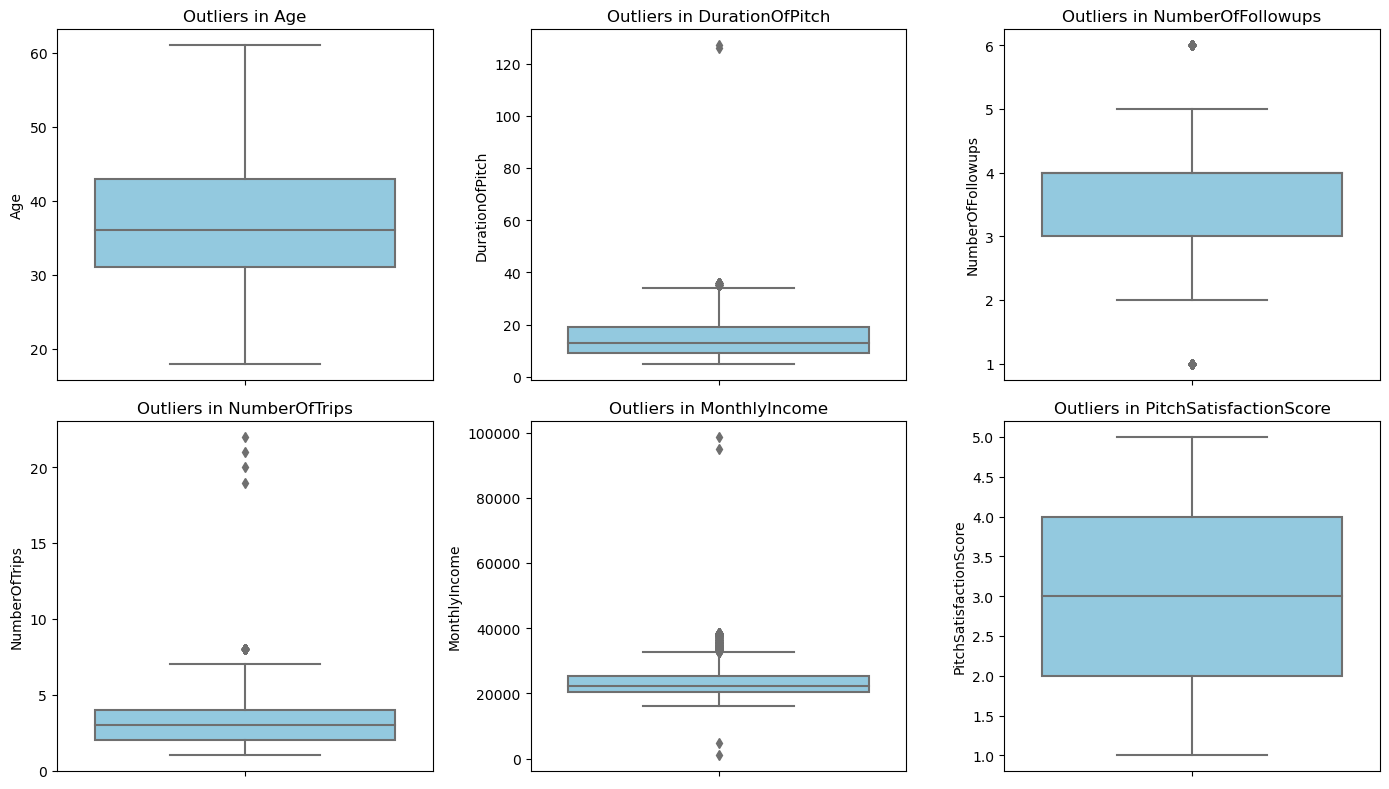

In [24]:
num_features = ['Age', 'DurationOfPitch', 'NumberOfFollowups', 
                'NumberOfTrips', 'MonthlyIncome', 'PitchSatisfactionScore']

plt.figure(figsize=(14, 8))
for i, col in enumerate(num_features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f"Outliers in {col}")
plt.tight_layout()
plt.show()

In [25]:
outlier_summary = {}

for col in num_features:
    if col != 'ProdTaken':  # skip target
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outlier_summary[col] = len(outliers)

pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier Count'])


,Outlier Count
Age,0
DurationOfPitch,108
NumberOfFollowups,310
NumberOfTrips,106
MonthlyIncome,366
PitchSatisfactionScore,0


## Univariate Analysis

### Target Variable Distribution

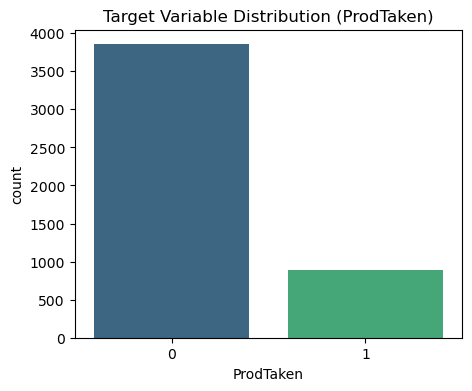

0    81.167053
1    18.832947
Name: ProdTaken, dtype: float64


In [26]:
plt.figure(figsize=(5, 4))
sns.countplot(x='ProdTaken', data=df, palette='viridis')
plt.title("Target Variable Distribution (ProdTaken)")
plt.show()
print(df['ProdTaken'].value_counts(normalize=True)*100)


### Numerical Columns

In [27]:
# Separate numeric columns except target
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('ProdTaken')  # remove target column
print("Numeric Columns:", num_cols)


Numeric Columns: ['Age', 'CityTier', 'DurationOfPitch', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting', 'MonthlyIncome']


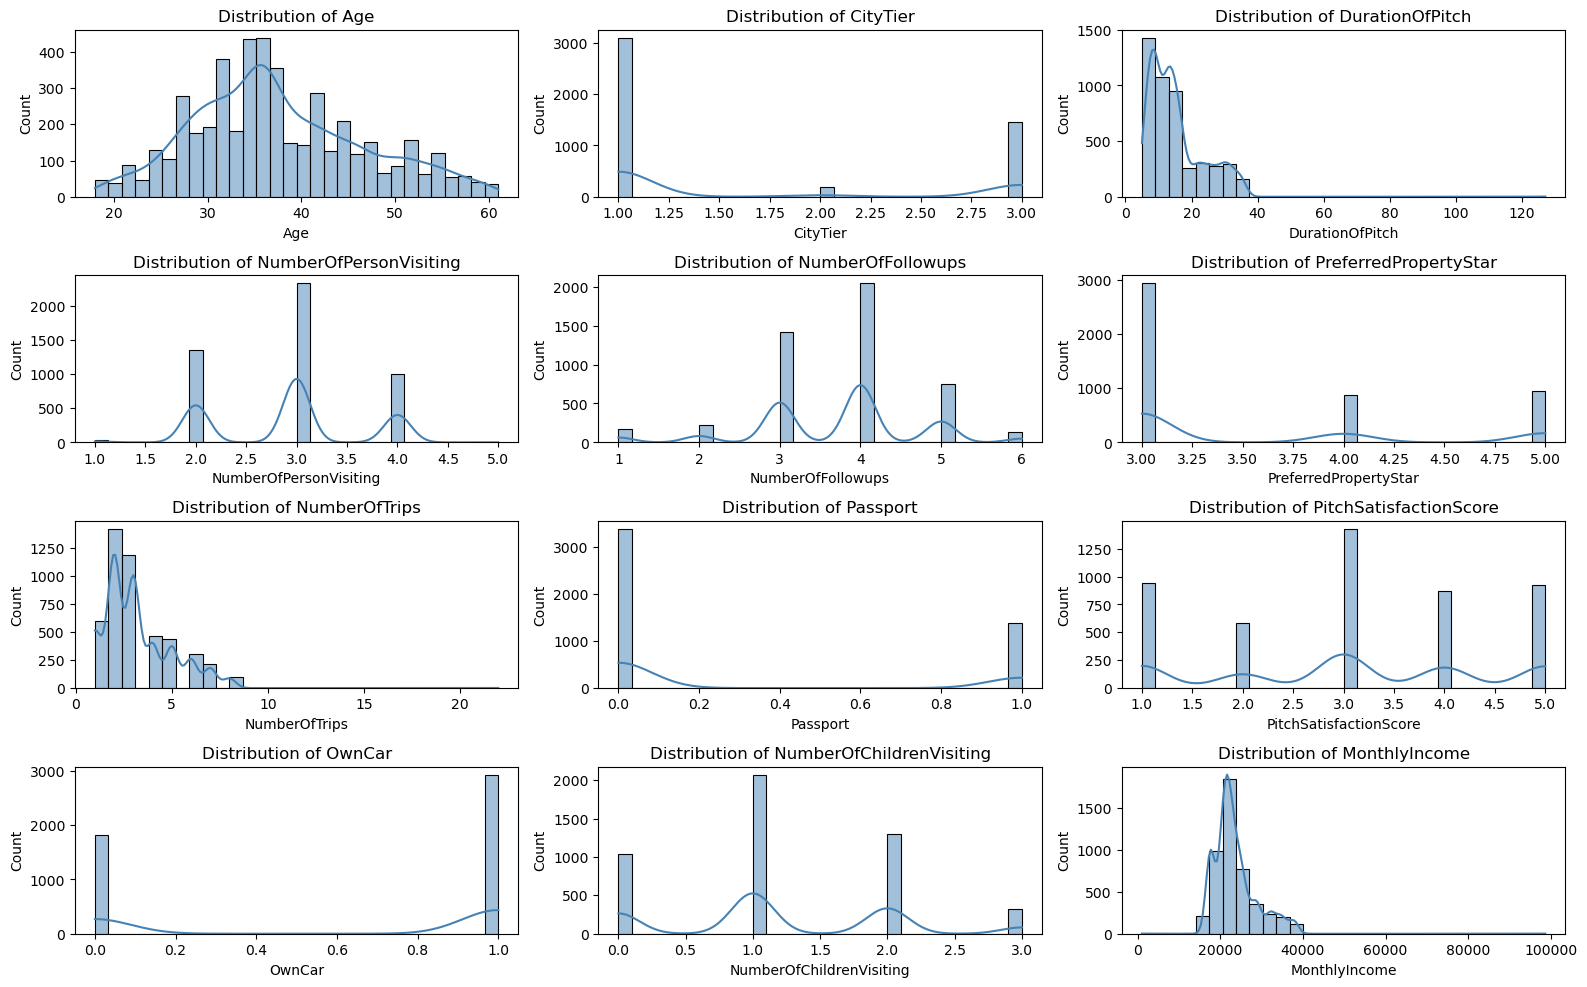

In [28]:
plt.figure(figsize=(16, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(5, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color='steelblue')
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()



### Categorical Columns

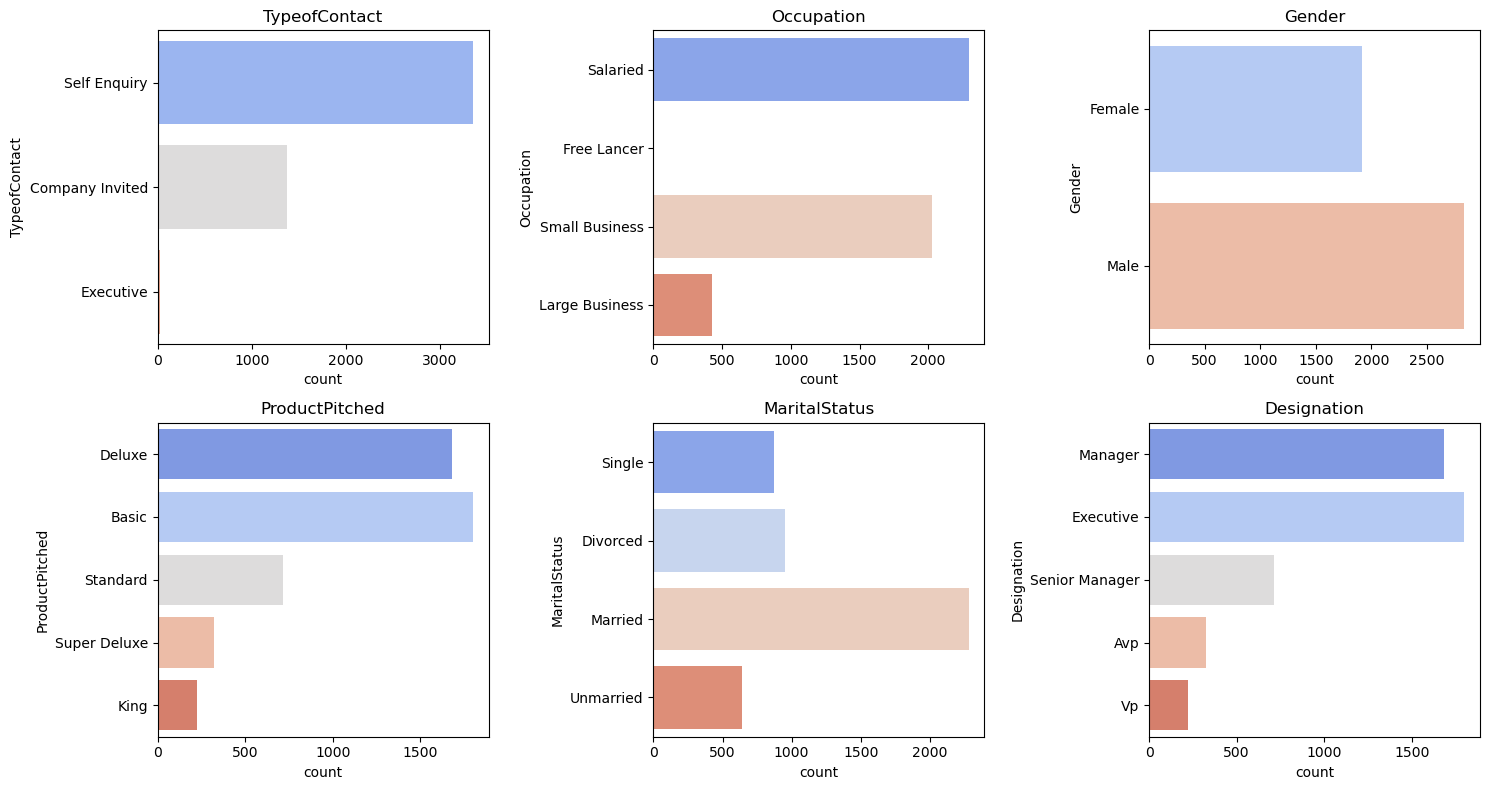

In [29]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']

plt.figure(figsize=(15,8))
for i, col in enumerate(cat_cols[:], 1):
    plt.subplot(2,3,i)
    sns.countplot(y=col, data=df, palette="coolwarm")
    plt.title(col)
plt.tight_layout()
plt.show()


## Bivariate Analysis (with Target Variable)

### Categorical features vs target

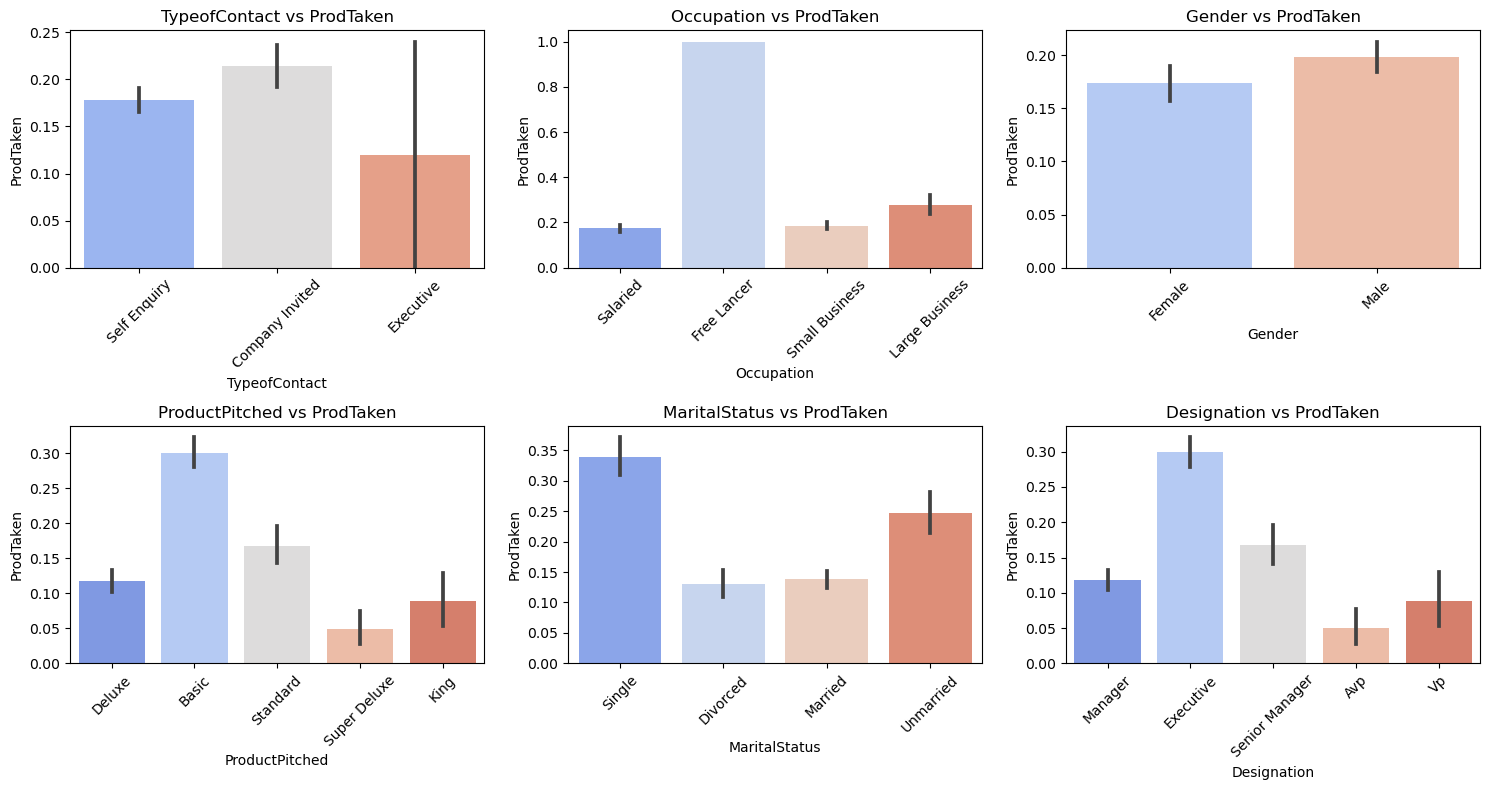

In [30]:
plt.figure(figsize=(15,8))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2,3,i)
    sns.barplot(x=col, y='ProdTaken', data=df, palette="coolwarm",
                estimator=lambda x: sum(x)/len(x))
    plt.title(f'{col} vs ProdTaken')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Numerical features vs target

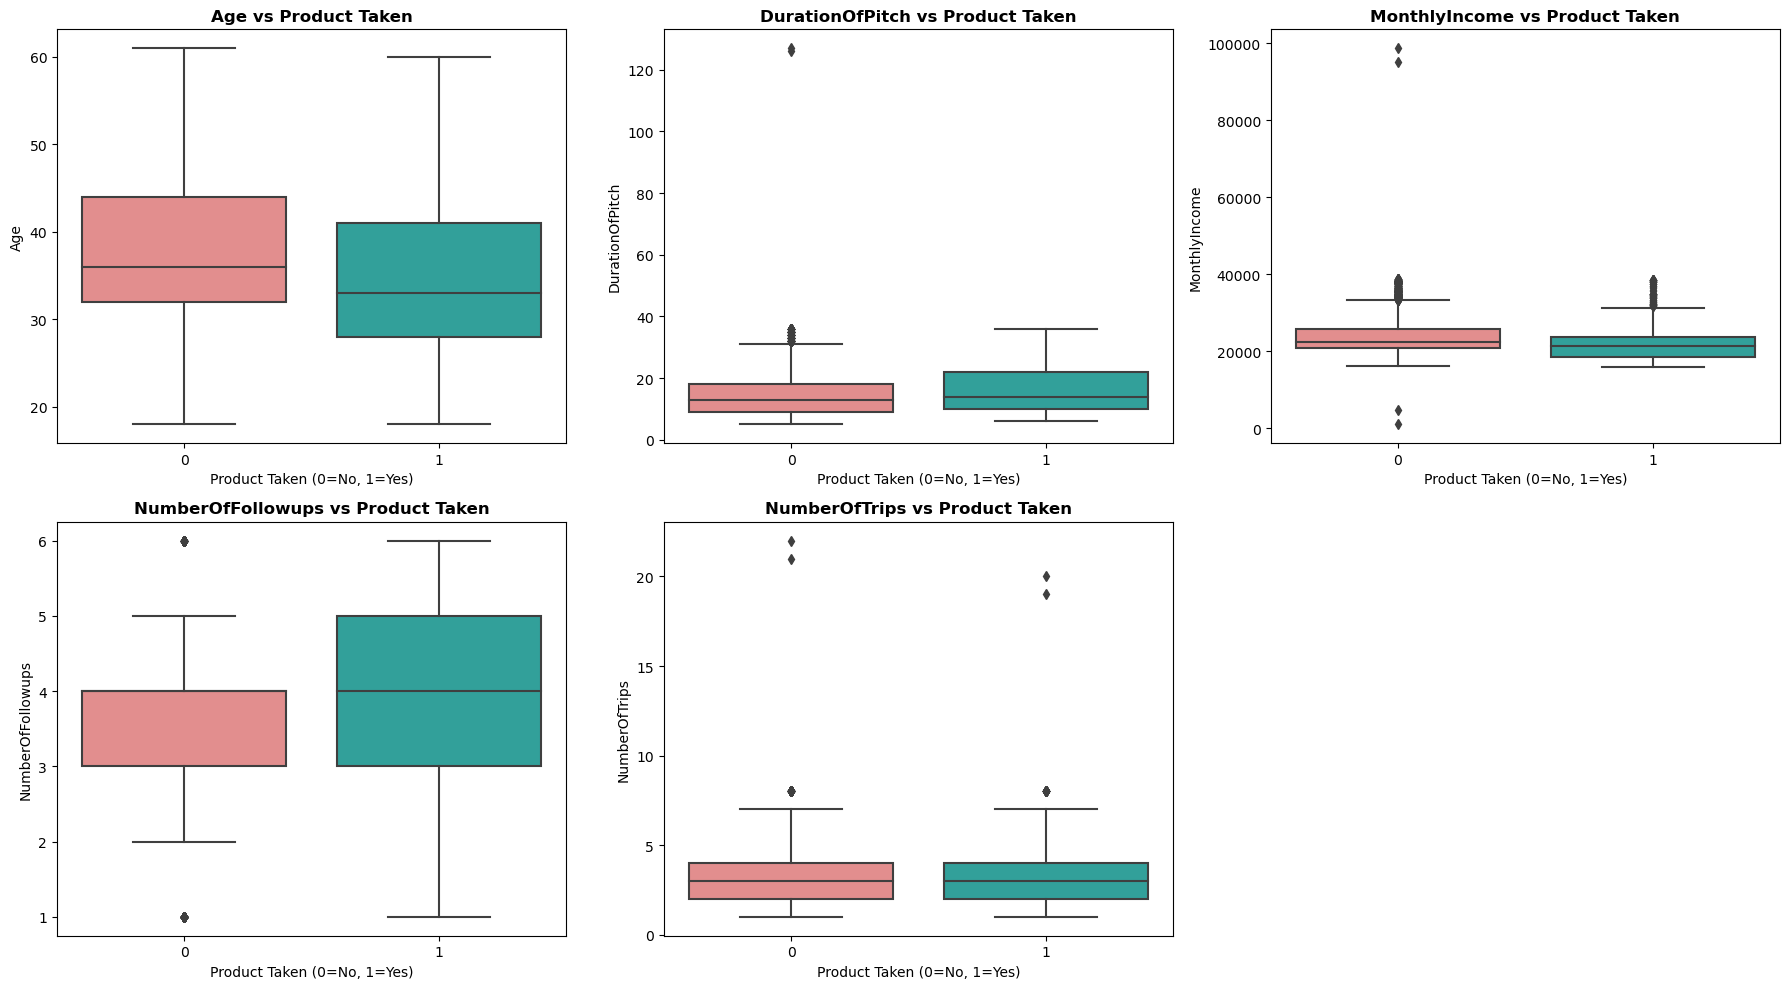

In [31]:
# Select key features for analysis
key_numerical = ['Age', 'DurationOfPitch', 'MonthlyIncome', 'NumberOfFollowups', 'NumberOfTrips']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(key_numerical[:6]):
    if feature in num_cols:
        # Create boxplot
        sns.boxplot(data=df, x='ProdTaken', y=feature, ax=axes[i], 
                   palette=['lightcoral', 'lightseagreen'])
        axes[i].set_title(f'{feature} vs Product Taken', fontweight='bold')
        axes[i].set_xlabel('Product Taken (0=No, 1=Yes)')
        axes[i].set_ylabel(feature)

# Hide empty subplots
for i in range(len(key_numerical), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

 HISTOGRAMS with KDE - Distribution Overlay


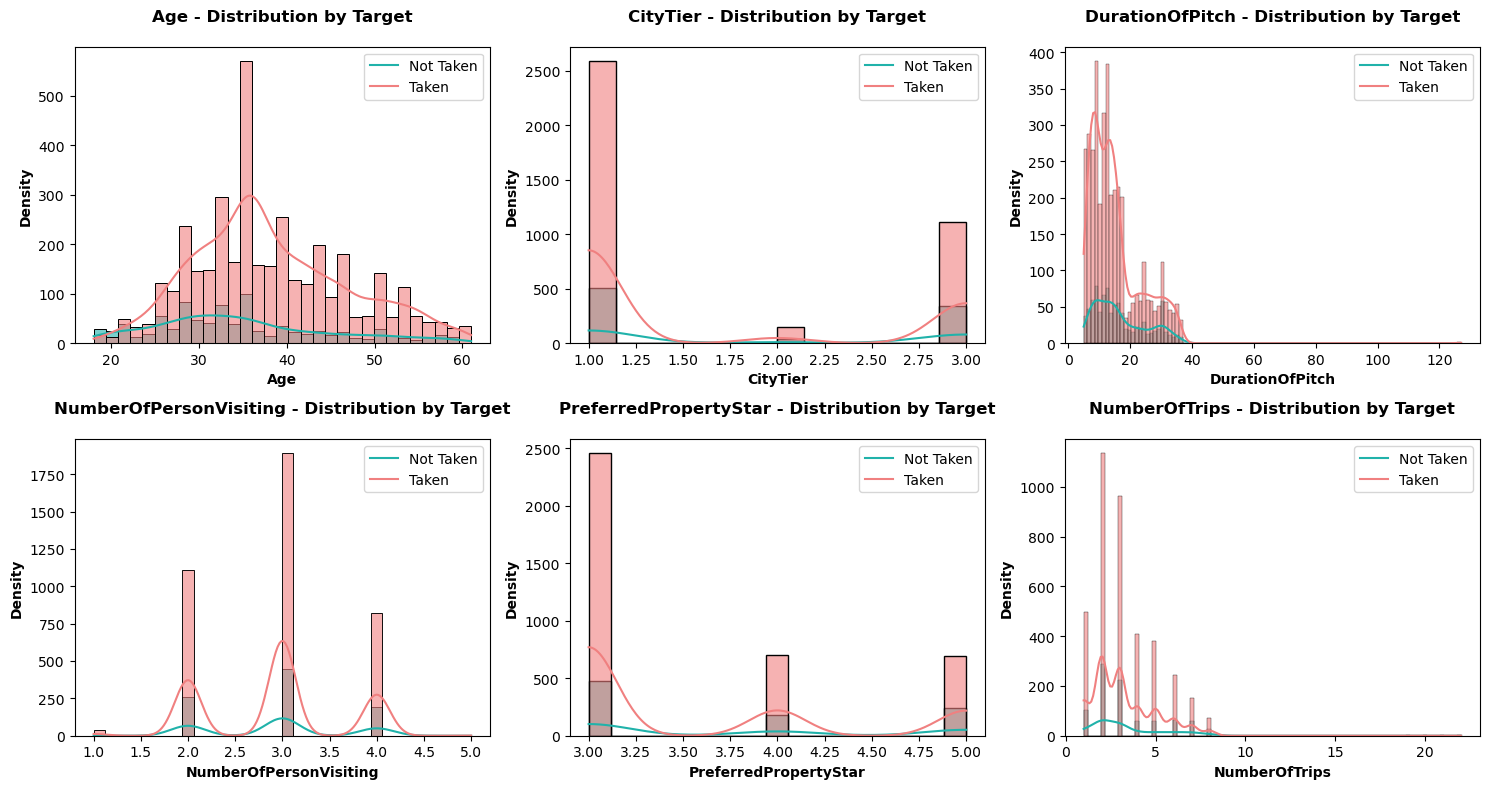

In [32]:
n_numericals = ['Age', 'CityTier', 'DurationOfPitch', 'NumberOfPersonVisiting', 'PreferredPropertyStar', 'NumberOfTrips']
print(" HISTOGRAMS with KDE - Distribution Overlay")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(n_numericals):
    sns.histplot(data=df, x=feature, hue='ProdTaken', ax=axes[i], 
                kde=True, alpha=0.6, palette={0: 'lightcoral', 1: 'lightseagreen'})
    axes[i].set_title(f'{feature} - Distribution by Target\n', fontweight='bold')
    axes[i].set_xlabel(feature, fontweight='bold')
    axes[i].set_ylabel('Density', fontweight='bold')
    axes[i].legend(['Not Taken', 'Taken'])

plt.tight_layout()
plt.show()

### Correlation Matrix (Numeric Relationships)

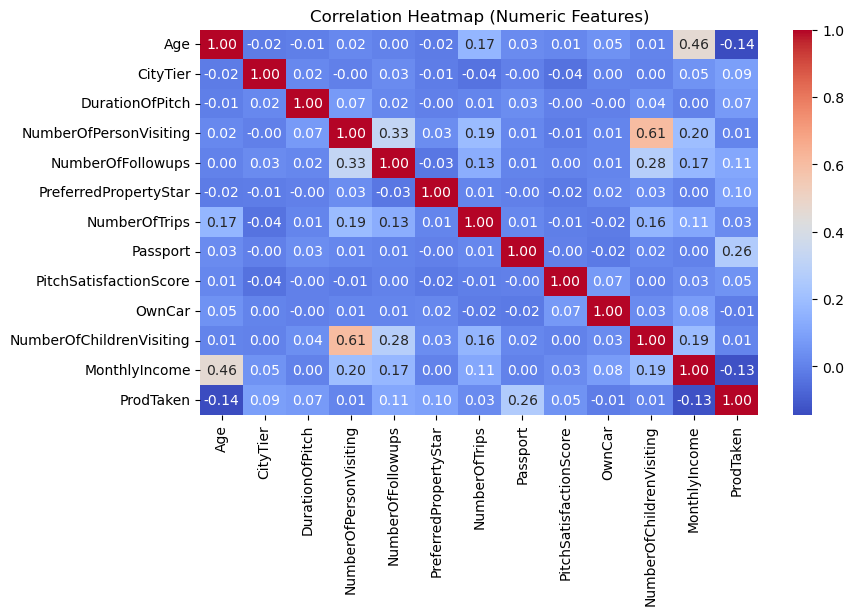

In [33]:
plt.figure(figsize=(9,5))
sns.heatmap(df[num_cols + ['ProdTaken']].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


In [34]:
#Copying data
df_model = df.copy()

# Prepare Dataset for Modeling

In [37]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

print("✅ df_model shape:", df_model.shape)
df_model.head()



✅ df_model shape: (4747, 19)


,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


### Define Target and Feature Columns

In [38]:
# Define target and features
target = 'ProdTaken'
X = df_model.drop(columns=[target, 'CustomerID'], errors='ignore')
y = df_model[target]

# Check target distribution
print("Target distribution (%):")
print(y.value_counts(normalize=True) * 100)


Target distribution (%):
0    81.167053
1    18.832947
Name: ProdTaken, dtype: float64


### Split Data into Train/Test Sets

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (3797, 18)
Testing set: (950, 18)


### Identify Column Types

In [41]:
# Explanation:
# Detect numeric and categorical columns from the training data (prevents leakage).

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)


Numeric columns: ['Age', 'CityTier', 'DurationOfPitch', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting', 'MonthlyIncome']
Categorical columns: ['TypeofContact', 'Occupation', 'Gender', 'ProductPitched', 'MaritalStatus', 'Designation']


### Data Preprocessing (Scaling & Encoding)

In [42]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


# Standardize numeric features (helps linear models). OneHot encode nominal categorical features.

# Define transformations
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False)

# Create column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ],
    remainder='drop'
)


### Evaluation Helpers

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

def pr_auc(y_true, y_scores):
    p, r, _ = precision_recall_curve(y_true, y_scores)
    return auc(r, p)

def top_decile_lift(y_true, y_scores):
    df_temp = pd.DataFrame({'y': y_true.values, 'p': y_scores})
    df_temp = df_temp.sort_values('p', ascending=False).reset_index(drop=True)
    top_n = int(0.1 * len(df_temp))
    lift = df_temp.loc[:top_n, 'y'].mean() / df_temp['y'].mean()
    return round(lift, 2)

def eval_model(name, y_true, y_pred, y_score):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_score)
    pra = pr_auc(y_true, y_score)
    lift = top_decile_lift(y_true, y_score)

    print(f"📈 {name}")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print(f"ROC-AUC: {roc:.4f} | PR-AUC: {pra:.4f} | Top-Decile Lift: {lift}x\n")
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

### Logistic Regression (Baseline Model)

📈 Logistic Regression (Baseline)
Accuracy: 0.7368 | Precision: 0.3894 | Recall: 0.6983 | F1: 0.5000
ROC-AUC: 0.7753 | PR-AUC: 0.5310 | Top-Decile Lift: 3.21x

              precision    recall  f1-score   support

           0       0.91      0.75      0.82       771
           1       0.39      0.70      0.50       179

    accuracy                           0.74       950
   macro avg       0.65      0.72      0.66       950
weighted avg       0.82      0.74      0.76       950



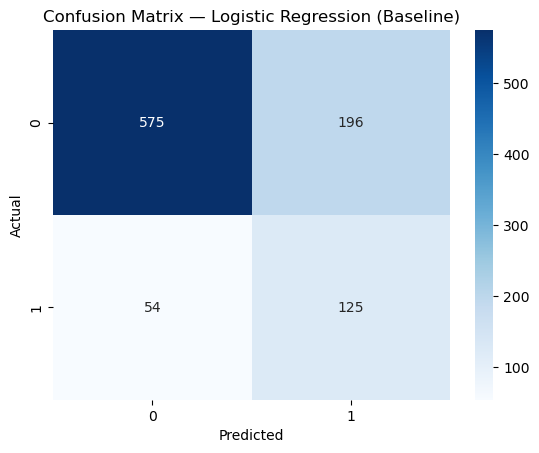

In [66]:
lr_pipe = Pipeline([
    ('pre', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
y_proba_lr = lr_pipe.predict_proba(X_test)[:, 1]

eval_model("Logistic Regression (Baseline)", y_test, y_pred_lr, y_proba_lr)

### Random Forest (Best Overall Model)

📈 Random Forest (Tuned)
Accuracy: 0.8800 | Precision: 0.7211 | Recall: 0.5922 | F1: 0.6503
ROC-AUC: 0.9188 | PR-AUC: 0.7531 | Top-Decile Lift: 4.2x

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       771
           1       0.72      0.59      0.65       179

    accuracy                           0.88       950
   macro avg       0.82      0.77      0.79       950
weighted avg       0.87      0.88      0.88       950



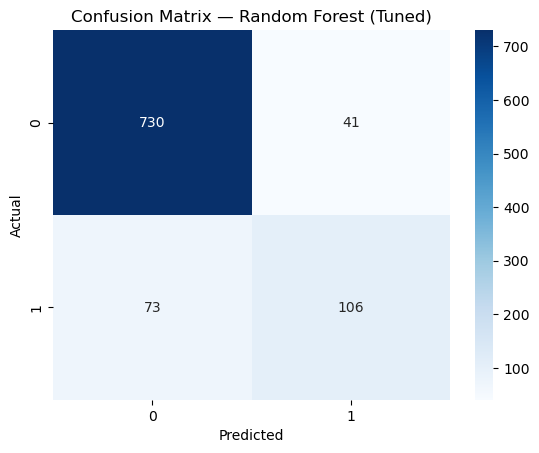

In [86]:
rf_pipe = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=150, max_depth=10, max_features='sqrt',
        class_weight='balanced', random_state=42
    ))
])

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]

eval_model("Random Forest (Tuned)", y_test, y_pred_rf, y_proba_rf)

### Gradient Boosting (Performance Model)

📈 Gradient Boosting (Sklearn)
Accuracy: 0.9021 | Precision: 0.8981 | Recall: 0.5419 | F1: 0.6760
ROC-AUC: 0.8930 | PR-AUC: 0.7757 | Top-Decile Lift: 4.92x

              precision    recall  f1-score   support

           0       0.90      0.99      0.94       771
           1       0.90      0.54      0.68       179

    accuracy                           0.90       950
   macro avg       0.90      0.76      0.81       950
weighted avg       0.90      0.90      0.89       950



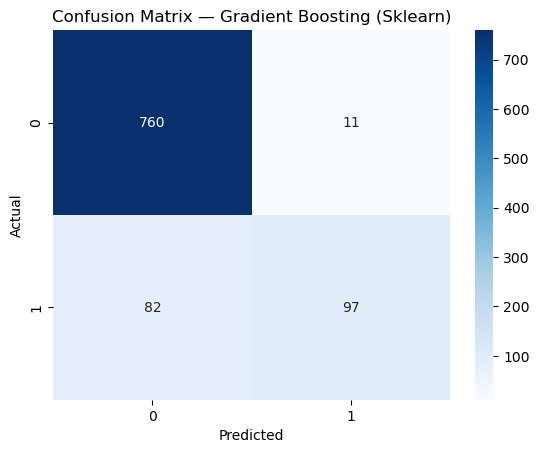

In [80]:
gb_pipe = Pipeline([
    ('pre', preprocessor),
    ('model', GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.08, max_depth=5, random_state=42))
])

gb_pipe.fit(X_train, y_train)
y_pred_gb = gb_pipe.predict(X_test)
y_proba_gb = gb_pipe.predict_proba(X_test)[:, 1]

eval_model("Gradient Boosting (Sklearn)", y_test, y_pred_gb, y_proba_gb)
best_model = gb_pipe
best_name = "GradientBoosting"


### Compare Model Performances

In [87]:
rows = [
    {"Model": "Logistic Regression", "Accuracy": accuracy_score(y_test, y_pred_lr),
     "Precision": precision_score(y_test, y_pred_lr), "Recall": recall_score(y_test, y_pred_lr),
     "F1": f1_score(y_test, y_pred_lr), "ROC_AUC": roc_auc_score(y_test, y_proba_lr),
     "TopDecileLift": top_decile_lift(y_test, y_proba_lr)},
    
    {"Model": "Random Forest", "Accuracy": accuracy_score(y_test, y_pred_rf),
     "Precision": precision_score(y_test, y_pred_rf), "Recall": recall_score(y_test, y_pred_rf),
     "F1": f1_score(y_test, y_pred_rf), "ROC_AUC": roc_auc_score(y_test, y_proba_rf),
     "TopDecileLift": top_decile_lift(y_test, y_proba_rf)},
    
    {"Model": "Gradient Boosting", "Accuracy": accuracy_score(y_test, y_pred_gb),
     "Precision": precision_score(y_test, y_pred_gb), "Recall": recall_score(y_test, y_pred_gb),
     "F1": f1_score(y_test, y_pred_gb), "ROC_AUC": roc_auc_score(y_test, y_proba_gb),
     "TopDecileLift": top_decile_lift(y_test, y_proba_gb)}
]

results_df = pd.DataFrame(rows).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
display(results_df)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,TopDecileLift
0,Random Forest,0.880000,0.721088,0.592179,0.650307,0.918752,4.20
1,Gradient Boosting,0.902105,0.898148,0.541899,0.675958,0.893007,4.92
2,Logistic Regression,0.736842,0.389408,0.698324,0.500000,0.775312,3.21


### Feature Importance (Gradient Boosting)

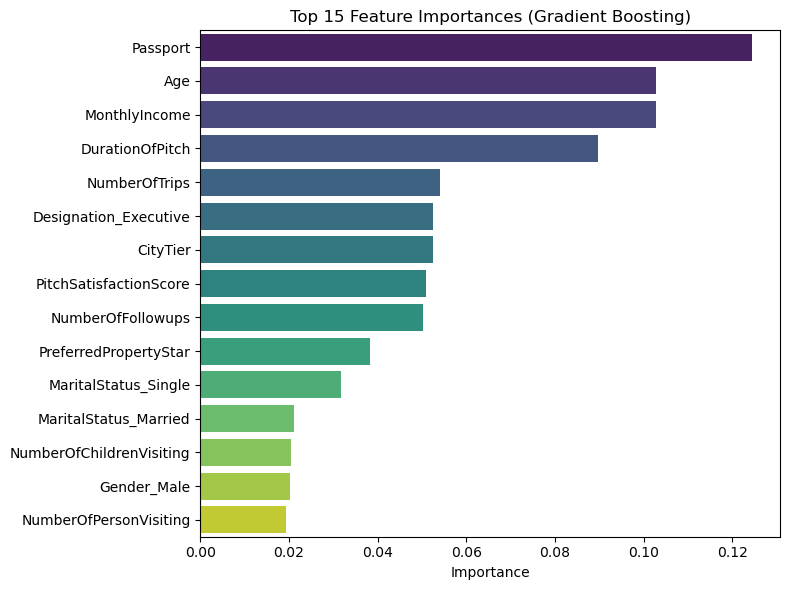

In [90]:
rf_model = rf_pipe.named_steps['model']
pre = rf_pipe.named_steps['pre']

# Get OneHot-encoded column names
ohe = pre.named_transformers_.get('cat')
ohe_cols = list(ohe.get_feature_names_out(cat_cols)) if ohe else []

feature_names = num_cols + ohe_cols
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Top 15 Feature Importances (Gradient Boosting)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


### Save Final Model

In [91]:
import joblib
joblib.dump(rf_pipeline, "final_tourism_model.pkl")
print(" Final Gradient Boosting model saved successfully!")


 Final Gradient Boosting model saved successfully!


### Business Insights

In [92]:
print("=== 🧠 Business Insights & Recommendations ===\n")

print("🔹 Key Drivers of Purchase:")
print("- MonthlyIncome — higher income → higher purchase chance")
print("- PitchSatisfactionScore — satisfied customers buy more")
print("- NumberOfFollowups — 3–4 followups improve success")
print("- NumberOfTrips — frequent travelers more likely to buy")
print("- DurationOfPitch — 15–25 min optimal range")
print("- PreferredPropertyStar — preference for higher-star hotels")

print("\n📊 Insights Summary:")
print("• Focus campaigns on Tier 1 & 2 cities; conversion rates are higher.")
print("• Maintain effective pitch durations and focus on satisfaction scoring.")
print("• Families and repeat travelers represent the most profitable customer group.")
print("• Use top 10% predicted leads (by probability) for first marketing contact.")
print("\n✅ Data-Driven Decision: Target premium, satisfied, frequent travelers with 3–4 personalized followups.")


=== 🧠 Business Insights & Recommendations ===

🔹 Key Drivers of Purchase:
- MonthlyIncome — higher income → higher purchase chance
- PitchSatisfactionScore — satisfied customers buy more
- NumberOfFollowups — 3–4 followups improve success
- NumberOfTrips — frequent travelers more likely to buy
- DurationOfPitch — 15–25 min optimal range
- PreferredPropertyStar — preference for higher-star hotels

📊 Insights Summary:
• Focus campaigns on Tier 1 & 2 cities; conversion rates are higher.
• Maintain effective pitch durations and focus on satisfaction scoring.
• Families and repeat travelers represent the most profitable customer group.
• Use top 10% predicted leads (by probability) for first marketing contact.

✅ Data-Driven Decision: Target premium, satisfied, frequent travelers with 3–4 personalized followups.
